In [1]:
%pip install jupyter
%pip install nltk
%pip install torch torchvision torchaudio
%pip install ultralytics
%pip install transformers[sentencepiece,torch]  # minimal needed
%pip install sentence-transformers
%pip install tf-keras
%pip install gradio --quiet

import os
import glob
import yaml
import re
import nltk
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt 
from PIL import Image
from ast import literal_eval

from ultralytics import YOLO
from nltk.stem import WordNetLemmatizer
from IPython.display import Image, display

nltk.download('wordnet')
nltk.download('omw-1.4')

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
zsh:1: no matches found: transformers[sentencepiece,torch]
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/ahmedalashi/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/ahmedalashi/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [17]:
ROOT_DIR = os.getcwd()
print("Current working directory:", ROOT_DIR)

SINGLE_INGREDIENT_DATA_YAML_PATH = os.path.join(ROOT_DIR, 'datasets', 'yolo_single_ingredient_dataset', 'data.yaml')
MULTI_INGREDIENT_DATA_YAML_PATH = os.path.join(ROOT_DIR, 'datasets', 'yolo_multi_ingredient_dataset', 'data.yaml')
ORIGINAL_YOLO_MODEL_PATH = os.path.join('models', 'original_yolo11s.pt')
FINE_TUNED_100_EPOCHS_YOLO_MODEL_PATH = os.path.join('models', 'yolo11s_100_epochs', 'weights', 'best.pt')
SINGLE_INGREDIENTS_VALID_IMAGES_PATH = os.path.join(ROOT_DIR, 'datasets', 'yolo_single_ingredient_dataset', 'valid', 'images')

# Recipes Dataset
RECIPE_CSV = os.path.join(ROOT_DIR, 'food_ingredients_and_recipes_dataset_with_images', 'archive', 'recipes.csv')
IMAGE_FOLDER = os.path.join(ROOT_DIR, 'food_ingredients_and_recipes_dataset_with_images', 'archive', 'images')
# Testing Images
TESTING_IMAGES_DIR = os.path.join(ROOT_DIR, 'datasets', 'testing_images')
TESTING_BLOCKED_IMAGES_DIR = os.path.join(ROOT_DIR, 'datasets', 'testing_blocked_images')

PREDICT_LABELS_DIR = os.path.join(ROOT_DIR, 'runs', 'detect', 'predict', 'labels')
TEST_LABELS_DIR = os.path.join(ROOT_DIR, 'runs', 'detect', 'testing_images', 'labels')

Current working directory: /Users/ahmedalashi/Desktop/Thesis Expirements


In [18]:
yolo_model = YOLO(ORIGINAL_YOLO_MODEL_PATH)

# yolo_model.train(data=DATA_YAML_PATH, epochs=60, imgsz=640) .. 30, 60, 100

In [21]:
trained_model = YOLO(FINE_TUNED_100_EPOCHS_YOLO_MODEL_PATH)

trained_model.predict(
    source=SINGLE_INGREDIENTS_VALID_IMAGES_PATH,
    model=FINE_TUNED_100_EPOCHS_YOLO_MODEL_PATH,
    save=True,
    save_txt=True,
    name='predict',
)



image 1/286 /Users/ahmedalashi/Desktop/Thesis Expirements/datasets/yolo_single_ingredient_dataset/valid/images/03fb45cacec89b7a2cd216bdfd960a5b3b926724_jpg.rf.e45dfeb9de325a325c90afdd7379396e.jpg: 640x640 1 carrot, 3 olives, 99.0ms
image 2/286 /Users/ahmedalashi/Desktop/Thesis Expirements/datasets/yolo_single_ingredient_dataset/valid/images/0d2ca3a6dfcbf92ed2939faac9fd40978cd58c63_jpg.rf.fb6f04d6cbbb9ce9c2706c5d034561aa.jpg: 640x640 15 onions, 74.9ms
image 3/286 /Users/ahmedalashi/Desktop/Thesis Expirements/datasets/yolo_single_ingredient_dataset/valid/images/34dccdbf7b249415e1688b16a253e3aaa85d3476_jpg.rf.502634b64ad3f82a62c642ed06f0084f.jpg: 640x640 2 milks, 75.4ms
image 4/286 /Users/ahmedalashi/Desktop/Thesis Expirements/datasets/yolo_single_ingredient_dataset/valid/images/38a508a82b2ad18941acec3ff5d5b6d898598511_jpg.rf.80f51ddefec5218be30a753751989fd9.jpg: 640x640 3 olive oils, 75.7ms
image 5/286 /Users/ahmedalashi/Desktop/Thesis Expirements/datasets/yolo_single_ingredient_dataset

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'banana', 1: 'bell pepper', 2: 'bulgur', 3: 'cabbage', 4: 'carrot', 5: 'cheese', 6: 'chicken', 7: 'chickpeas', 8: 'cucumber', 9: 'egg', 10: 'eggplant', 11: 'farfalle pasta', 12: 'fusilli pasta', 13: 'garlic', 14: 'green pepper', 15: 'ground meat', 16: 'ketchup', 17: 'lemon', 18: 'margarine', 19: 'mayonnaise', 20: 'milk', 21: 'mushroom', 22: 'olive', 23: 'olive oil', 24: 'onion', 25: 'parsley', 26: 'potato', 27: 'red lentils', 28: 'rice', 29: 'sausage', 30: 'spaghetti', 31: 'tomato', 32: 'tomato paste', 33: 'turkish dumplings', 34: 'yogurt', 35: 'zucchini'}
 obb: None
 orig_img: array([[[ 72, 116, 133],
         [ 52,  98, 115],
         [ 60, 111, 131],
         ...,
         [149, 151, 152],
         [180, 182, 183],
         [203, 205, 206]],
 
        [[ 58, 100, 119],
         [ 39,  85, 103],
         [ 54, 104, 124],
         ...,

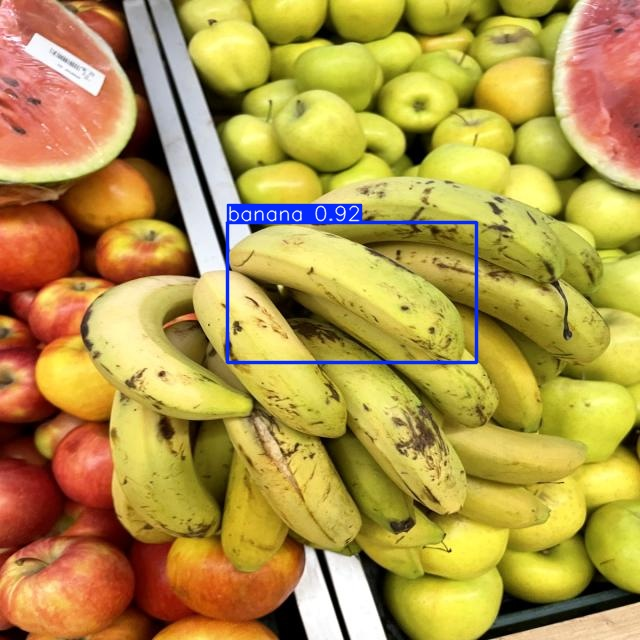

In [22]:
# Print the first predicted image
for image_path in glob.glob(os.path.join(ROOT_DIR, 'runs', 'detect', 'predict', '*.jpg'))[:1]:
    display(Image(filename=image_path, height=400))
    print('\n')

In [24]:
predict_result = trained_model.predict(
    source=TESTING_IMAGES_DIR,
    model=FINE_TUNED_100_EPOCHS_YOLO_MODEL_PATH,
    save=True,
    save_txt=True,
    project=os.path.join(ROOT_DIR, 'runs', 'detect'),
    name='testing_images'
)


image 1/5 /Users/ahmedalashi/Desktop/Thesis Expirements/datasets/testing_images/banana_big.jpg: 640x512 1 banana, 1 rice, 98.6ms
image 2/5 /Users/ahmedalashi/Desktop/Thesis Expirements/datasets/testing_images/cucumber.jpg: 640x640 (no detections), 84.0ms
image 3/5 /Users/ahmedalashi/Desktop/Thesis Expirements/datasets/testing_images/eggplant.webp: 640x640 1 parsley, 79.8ms
image 4/5 /Users/ahmedalashi/Desktop/Thesis Expirements/datasets/testing_images/rice.png: 640x640 2 rices, 1 yogurt, 73.1ms
image 5/5 /Users/ahmedalashi/Desktop/Thesis Expirements/datasets/testing_images/tomato_and_lemon.jpg: 448x640 1 lemon, 3 tomatos, 55.4ms
Speed: 2.3ms preprocess, 78.2ms inference, 0.7ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /Users/ahmedalashi/Desktop/Thesis Expirements/runs/detect/testing_images
4 labels saved to /Users/ahmedalashi/Desktop/Thesis Expirements/runs/detect/testing_images/labels


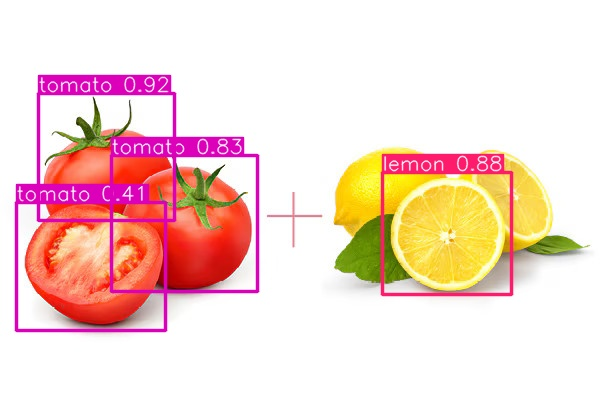

In [36]:

for image_path in glob.glob(os.path.join(ROOT_DIR, 'runs', 'detect', 'testing_images', '*.jpg'))[:1]:
    display(Image(filename=image_path, height=400))
    print('\n')

In [37]:
with open(SINGLE_INGREDIENT_DATA_YAML_PATH, 'r') as file:
    class_names = yaml.safe_load(file)['names']
print("Class names loaded from YAML file:", class_names)
print(f"Number of classes: {len(class_names)}")

Class names loaded from YAML file: ['banana', 'bell pepper', 'bulgur', 'cabbage', 'carrot', 'cheese', 'chicken', 'chickpeas', 'cucumber', 'egg', 'eggplant', 'farfalle pasta', 'fusilli pasta', 'garlic', 'green pepper', 'ground meat', 'ketchup', 'lemon', 'margarine', 'mayonnaise', 'milk', 'mushroom', 'olive', 'olive oil', 'onion', 'parsley', 'potato', 'red lentils', 'rice', 'sausage', 'spaghetti', 'tomato', 'tomato paste', 'turkish dumplings', 'yogurt', 'zucchini']
Number of classes: 36


In [38]:
detected_classes = set()

for label_file in glob.glob(os.path.join(TEST_LABELS_DIR, '*.txt')):
    print(f"Detections in {os.path.basename(label_file)}:")
    with open(label_file, 'r') as f:
        print(f"Contents of {label_file}:")
        lines = f.readlines()
        for line in lines:
            print(line.strip())
            parts = line.strip().split()
            if len(parts) >= 5:
                class_id = int(parts[0])
                class_name = class_names[class_id]
                detected_classes.add(class_name)

                confidence = float(parts[5]) if len(parts) == 6 else None
                if confidence is not None:
                    print(f" - {class_name} (Confidence: {confidence:.2f})")
                else:
                    print(f" - {class_name}")
    print('\n')

detected_classes_list = list(detected_classes)
print("Unique detected classes/ingredients:")
print(detected_classes_list)

Detections in tomato_and_lemon.txt:
Contents of /Users/ahmedalashi/Desktop/Thesis Expirements/runs/detect/testing_images/labels/tomato_and_lemon.txt:
31 0.177809 0.393611 0.227343 0.317304
 - tomato
17 0.745305 0.584006 0.215733 0.306807
 - lemon
31 0.307116 0.558536 0.243748 0.339866
 - tomato
31 0.152118 0.666207 0.247708 0.317964
 - tomato


Detections in cucumber.txt:
Contents of /Users/ahmedalashi/Desktop/Thesis Expirements/runs/detect/testing_images/labels/cucumber.txt:
25 0.89932 0.0994987 0.201361 0.198931
 - parsley
8 0.500823 0.678853 0.303548 0.184001
 - cucumber


Detections in eggplant.txt:
Contents of /Users/ahmedalashi/Desktop/Thesis Expirements/runs/detect/testing_images/labels/eggplant.txt:
10 0.355414 0.491371 0.280555 0.739413
 - eggplant


Detections in banana_big.txt:
Contents of /Users/ahmedalashi/Desktop/Thesis Expirements/runs/detect/testing_images/labels/banana_big.txt:
9 0.516232 0.46781 0.217161 0.2145
 - egg
0 0.300709 0.467352 0.387382 0.658758
 - banana
9 

In [28]:
from IPython.display import display
# pd is not defined in the current context, so we need to re-import it
import pandas as pd
import os
# Define the path to the CSV file
ROOT_DIR = os.getcwd()

# Load the archive.csv file
archive_df = pd.read_csv(RECIPE_CSV)

# Display the first 10 rows of the DataFrame
display(archive_df.head(10))

,Unnamed: 0,Title,Ingredients,Instructions,Image_Name,Cleaned_Ingredients
0,0,Miso-Butter Roast Chicken With Acorn...,"['1 (3½–4-lb.) whole chicken', '2¾ t...","Pat chicken dry with paper towels, s...",miso-butter-roast-chicken-acorn-squa...,"['1 (3½–4-lb.) whole chicken', '2¾ t..."
1,1,Crispy Salt and Pepper Potatoes,"['2 large egg whites', '1 pound new ...",Preheat oven to 400°F and line a rim...,crispy-salt-and-pepper-potatoes-dan-...,"['2 large egg whites', '1 pound new ..."
2,2,Thanksgiving Mac and Cheese,"['1 cup evaporated milk', '1 cup who...",Place a rack in middle of oven; preh...,thanksgiving-mac-and-cheese-erick-wi...,"['1 cup evaporated milk', '1 cup who..."
3,3,Italian Sausage and Bread Stuffing,['1 (¾- to 1-pound) round Italian lo...,Preheat oven to 350°F with rack in m...,italian-sausage-and-bread-stuffing-2...,['1 (¾- to 1-pound) round Italian lo...
4,4,Newton's Law,"['1 teaspoon dark brown sugar', '1 t...",Stir together brown sugar and hot wa...,newtons-law-apple-bourbon-cocktail,"['1 teaspoon dark brown sugar', '1 t..."
5,5,Warm Comfort,"['2 chamomile tea bags', '1½ oz. rep...",Place 2 chamomile tea bags in a heat...,warm-comfort-tequila-chamomile-toddy,"['2 chamomile tea bags', '1½ oz. rep..."
6,6,Apples and Oranges,"['3 oz. Grand Marnier', '1 oz. Amaro...","Add 3 oz. Grand Marnier, 1 oz. Amaro...",apples-and-oranges-spiked-cider,"['3 oz. Grand Marnier', '1 oz. Amaro..."
7,7,Turmeric Hot Toddy,"['¼ cup granulated sugar', '¾ tsp. g...","For the turmeric syrup, combine ½ cu...",turmeric-hot-toddy-claire-sprouse,"['¼ cup granulated sugar', '¾ tsp. g..."
8,8,Instant Pot Lamb Haleem,['¾ cup assorted dals (such as chana...,"Combine dals, rice, and barley in a ...",instant-pot-lamb-haleem,['¾ cup assorted dals (such as chana...
9,9,Spiced Lentil and Caramelized Onion ...,['1 (14.5-ounce) can basic lentil so...,Place an oven rack in the center of ...,spiced-lentil-and-caramelized-onion-...,['1 (14.5-ounce) can basic lentil so...


In [29]:
pd.set_option('display.max_colwidth', 40)  # Limit column width

styled_df = archive_df.head(10).T.style.set_table_styles([
    {'selector': 'td', 'props': [('max-width', '150px'), ('overflow', 'hidden'), ('text-overflow', 'ellipsis'), ('white-space', 'nowrap')]},
    {'selector': 'th', 'props': [('font-weight', 'bold')]}
])
display(styled_df)

In [40]:
lemmatizer = WordNetLemmatizer()

def preprocess_ingredients(ingredients):
    processed = []
    for ingredient in ingredients:
        ingredient = re.sub(r'[^a-zA-Z]', ' ', ingredient.lower()).strip()
        ingredient = lemmatizer.lemmatize(ingredient)
        processed.append(ingredient)
    return list(set(processed))

processed_ingredients = preprocess_ingredients(detected_classes)

In [31]:
df = pd.read_csv(RECIPE_CSV)
df['Cleaned_Ingredients'] = df['Cleaned_Ingredients'].apply(literal_eval)
df['Tokenized_Ingredients'] = df['Cleaned_Ingredients'].apply(
    lambda x: [word for ingredient in x for word in ingredient.split()]
)
df['Processed_Ingredients'] = df['Tokenized_Ingredients'].apply(
    lambda x: [lemmatizer.lemmatize(re.sub(r'[^a-zA-Z]', ' ', i.lower()).strip()) for i in x]
)
df['Processed_Ingredients'] = df['Processed_Ingredients'].apply(
    lambda x: list(filter(None, set(x)))
)

#! # Uncomment the following lines if you want the system to suggest only recipes that contain the detected ingredients.
# ingredient_set = set(class_names)  # Assuming class_names contains valid ingredient names
# print("Ingredient set for filtering:", ingredient_set)
# df['Processed_Ingredients'] = df['Processed_Ingredients'].apply(
#     lambda x: [ingredient for ingredient in x if ingredient in ingredient_set]
# )
# print("Processed ingredients after filtering:\n", df['Processed_Ingredients'].head(100))

In [32]:
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer('all-MiniLM-L6-v2')
query_embedding = embed_model.encode([" ".join(processed_ingredients)])
recipe_embeddings = embed_model.encode(df['Processed_Ingredients'].apply(lambda x: " ".join(x)))

In [33]:
# Create a DataFrame to show the process of ingredients before and after pre-processing

# Add the embeddings to the DataFrame
df['Embeddings'] = df['Processed_Ingredients'].apply(
    lambda x: embed_model.encode(" ".join(x))
)

# Then add to your table
ingredients_table = pd.DataFrame({
    "Cleaned Ingredients": df['Cleaned_Ingredients'],
    "Tokenized Ingredients": df['Tokenized_Ingredients'],
    "Processed Ingredients": df['Processed_Ingredients'],
    "MiniLM Embeddings": df['Embeddings'].apply(lambda x: f"[{', '.join([f'{v:.3f}' for v in x[:5]])}, ...]")  # Truncate to show first 5 dimensions
})


# Display the table with better formatting
styled_table = ingredients_table.head(3).style.set_properties(**{
    'text-align': 'left',
    'background-color': '#FFFFFF',
    'border': '1px solid black',
    'font-size': '14px',
    'color': '#000000',
    'padding': '5px'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#FFFFFF'), ('text-align', 'center'), ('border', '1px solid black'), ('font-weight', 'bold'), ('color', '#000000')]}
])

display(styled_table)

,Cleaned Ingredients,Tokenized Ingredients,Processed Ingredients,MiniLM Embeddings
0,"['1 (3½–4-lb.) whole chicken', '2¾ tsp. kosher salt, divided, plus more', '2 small acorn squash (about 3 lb. total)', '2 Tbsp. finely chopped sage', '1 Tbsp. finely chopped rosemary', '6 Tbsp. unsalted butter, melted, plus 3 Tbsp. room temperature', '¼ tsp. ground allspice', 'Pinch of crushed red pepper flakes', 'Freshly ground black pepper', '⅓ loaf good-quality sturdy white bread, torn into 1"" pieces (about 2½ cups)', '2 medium apples (such as Gala or Pink Lady; about 14 oz. total), cored, cut into 1"" pieces', '2 Tbsp. extra-virgin olive oil', '½ small red onion, thinly sliced', '3 Tbsp. apple cider vinegar', '1 Tbsp. white miso', '¼ cup all-purpose flour', '2 Tbsp. unsalted butter, room temperature', '¼ cup dry white wine', '2 cups unsalted chicken broth', '2 tsp. white miso', 'Kosher salt', 'freshly ground pepper']","['1', '(3½–4-lb.)', 'whole', 'chicken', '2¾', 'tsp.', 'kosher', 'salt,', 'divided,', 'plus', 'more', '2', 'small', 'acorn', 'squash', '(about', '3', 'lb.', 'total)', '2', 'Tbsp.', 'finely', 'chopped', 'sage', '1', 'Tbsp.', 'finely', 'chopped', 'rosemary', '6', 'Tbsp.', 'unsalted', 'butter,', 'melted,', 'plus', '3', 'Tbsp.', 'room', 'temperature', '¼', 'tsp.', 'ground', 'allspice', 'Pinch', 'of', 'crushed', 'red', 'pepper', 'flakes', 'Freshly', 'ground', 'black', 'pepper', '⅓', 'loaf', 'good-quality', 'sturdy', 'white', 'bread,', 'torn', 'into', '1""', 'pieces', '(about', '2½', 'cups)', '2', 'medium', 'apples', '(such', 'as', 'Gala', 'or', 'Pink', 'Lady;', 'about', '14', 'oz.', 'total),', 'cored,', 'cut', 'into', '1""', 'pieces', '2', 'Tbsp.', 'extra-virgin', 'olive', 'oil', '½', 'small', 'red', 'onion,', 'thinly', 'sliced', '3', 'Tbsp.', 'apple', 'cider', 'vinegar', '1', 'Tbsp.', 'white', 'miso', '¼', 'cup', 'all-purpose', 'flour', '2', 'Tbsp.', 'unsalted', 'butter,', 'room', 'temperature', '¼', 'cup', 'dry', 'white', 'wine', '2', 'cups', 'unsalted', 'chicken', 'broth', '2', 'tsp.', 'white', 'miso', 'Kosher', 'salt', 'freshly', 'ground', 'pepper']","['thinly', 'cider', 'acorn', 'oz', 'chopped', 'lady', 'cup', 'sage', 'oil', 'lb', 'squash', 'kosher', 'crushed', 'salt', 'black', 'sliced', 'plus', 'ground', 'pepper', 'loaf', 'whole', 'small', 'melted', 'flake', 'total', 'torn', 'such', 'gala', 'cored', 'onion', 'broth', 'bread', 'pink', 'divided', 'about', 'sturdy', 'unsalted', 'chicken', 'flour', 'apple', 'finely', 'red', 'extra virgin', 'vinegar', 'butter', 'a', 'miso', 'room', 'freshly', 'more', 'tsp', 'rosemary', 'piece', 'allspice', 'wine', 'tbsp', 'olive', 'medium', 'white', 'all purpose', 'dry', 'of', 'pinch', 'into', 'or', 'good quality', 'temperature', 'cut']","[-0.033, 0.033, 0.025, 0.070, 0.077, ...]"
1,"['2 large egg whites', '1 pound new potatoes (about 1 inch in diameter)', '2 teaspoons kosher salt', '¾ teaspoon finely ground black pepper', '1 teaspoon finely chopped rosemary', '1 teaspoon finely chopped thyme', '1 teaspoon finely chopped parsley']","['2', 'large', 'egg', 'whites', '1', 'pound', 'new', 'potatoes', '(about', '1', 'inch', 'in', 'diameter)', '2', 'teaspoons', 'kosher', 'salt', '¾', 'teaspoon', 'finely', 'ground', 'black', 'pepper', '1', 'teaspoon', 'finely', 'chopped', 'rosemary', '1', 'teaspoon', 'finely', 'chopped', 'thyme', '1', 'teaspoon', 'finely', 'chopped', 'parsley']","['pound', 'potato', 'thyme', 'chopped', 'kosher', 'black', 'salt', 'in', 'ground', 'inch', 'diameter', 'large', 'pepper', 'teaspoon', 'about', 'egg', 'finely', 'parsley', 'rosemary', 'white', 'new']","[-0.052, -0.013, -0.025, -0.046, 0.093, ...]"
2,"['1 cup evaporated milk', '1 cup whole milk', '1 tsp. garlic powder', '1 tsp. onion powder', '1 tsp. smoked paprika', '½ tsp. freshly ground black pepper', '1 tsp. kosher salt, plus more', '2 lb. extra-sharp cheddar, coarsely grated', '4 oz. full-fat cream cheese', '1 lb. elbow macaroni']","['1', 'cup', 'evaporated', 'milk', '1', 'cup', 'whole', 'milk', '1', 'tsp.', 'garlic', 'powd

Detected Ingredients: eggplant, potato, banana, rice, egg, lemon, parsley, cucumber, tomato, yogurt


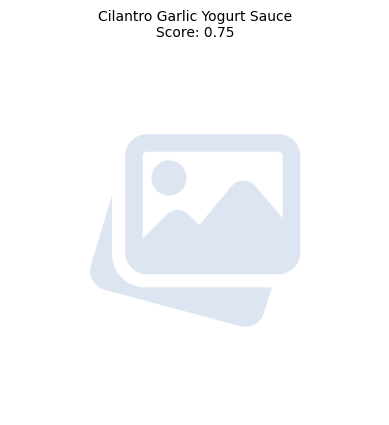

Recipe 1: Cilantro Garlic Yogurt Sauce
Ingredients: ['1 1/2 cups plain whole-milk Greek-style yogurt', '3/4 cup finely chopped cilantro', '4 1/2 tablespoons fresh lemon juice', '1 1/2 teaspoons finely chopped garlic', '3/4 teaspoon cayenne']
Instructions: Stir together all ingredients with 1 teaspoon salt (or to taste), then chill, covered, at least 30 minutes (for flavors to blend). Bring to room temperature before serving.
Similarity Score: 0.75
--------------------------------------------------------------------------------


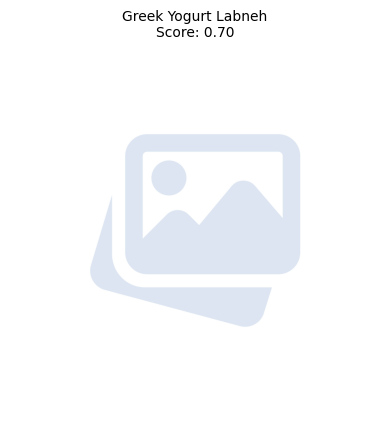

Recipe 2: Greek Yogurt Labneh
Ingredients: ['2 cups plain 2% fat or whole Fage Greek yogurt', '1/2 cup (or more) good-quality extra-virgin olive oil', '3 tablespoons finely minced fresh herbs (such as tarragon, parsley, and chives)', '1/2 teaspoon finely grated lemon zest', 'Kosher salt and freshly ground black pepper', 'Cheesecloth']
Instructions: Line a large sieve with cheesecloth; set over a medium deep bowl. Place yogurt in sieve. Gather edges of cheesecloth to cover yogurt. Place in refrigerator and let drain for 2-3 days.
Gently squeeze out any excess liquid; discard liquid in bowl (yogurt will be very thick and resemble soft goat cheese). Roll yogurt into 3/4" balls. Place in an 8-ounce glass jar.
Whisk oil, herbs, and lemon zest in a small bowl to combine. Season with salt and pepper. Pour over yogurt in jar. Cover; place in refrigerator and let marinate for at least 8 hours and up to 2 weeks.
Similarity Score: 0.70
-------------------------------------------------------------

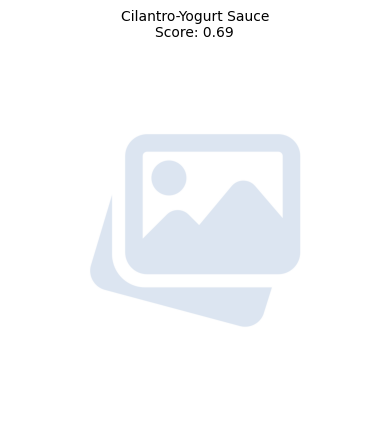

Recipe 3: Cilantro-Yogurt Sauce
Ingredients: ['1/2 small onion, finely chopped', '2 cups chopped fresh cilantro', '1 1/2 cups whole-milk yogurt (not Greek)', '2 tablespoons chopped fresh mint', '1/4 teaspoon ground coriander', '2 tablespoons (or more) fresh lemon juice', 'Kosher salt, freshly ground pepper']
Instructions: Combine onion, cilantro, yogurt, mint, coriander, and 2 tablespoons lemon juice in a medium bowl. Season sauce with salt, pepper, and more lemon juice, if desired.
DO AHEAD: Sauce can be made 1 day ahead. Cover and chill.
Similarity Score: 0.69
--------------------------------------------------------------------------------


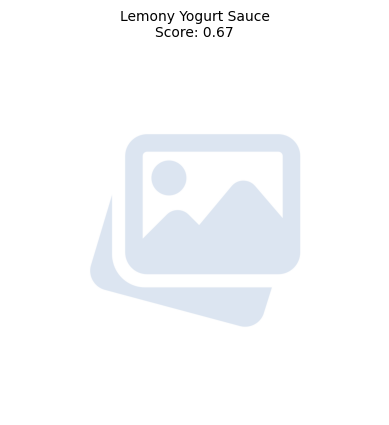

Recipe 4: Lemony Yogurt Sauce
Ingredients: ['6 Tbsp. fresh lemon juice', '1 garlic clove, finely grated', '1 tsp. kosher salt', '1 tsp. freshly ground black pepper', '2 cups plain whole-milk Greek yogurt']
Instructions: Whisk lemon juice, garlic, salt, and pepper into yogurt in a medium bowl to evenly distribute.
Sauce can be made 1 day ahead. Cover and chill.
Similarity Score: 0.67
--------------------------------------------------------------------------------


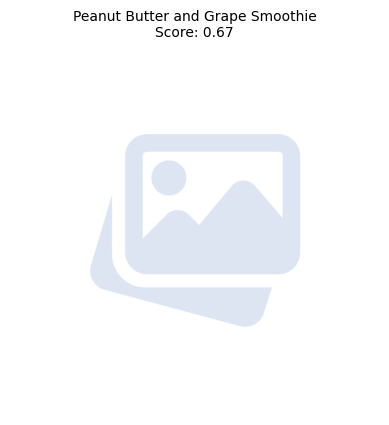

Recipe 5: Peanut Butter and Grape Smoothie
Ingredients: ['1 tablespoon peanut butter', '1 1/2 cups frozen seedless grapes', '1/2 banana, sliced', '1/2 cup low-fat Greek yogurt', '1/2 cup almond milk, or regular low-fat milk']
Instructions: Place ingredients in blender in the order listed and blend until smooth.
Similarity Score: 0.67
--------------------------------------------------------------------------------


In [43]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

DEFAULT_IMAGE = 'default_picture.png'

# Calculate cosine similarities
similarities = cosine_similarity(query_embedding, recipe_embeddings)
top_indices = np.argsort(similarities[0])[-5:][::-1]
print(f"Detected Ingredients: {', '.join(processed_ingredients)}")

# Show each recommended recipe one by one
for i, idx in enumerate(top_indices):
    title = df.iloc[idx]['Title']
    ingredients = df.iloc[idx]['Ingredients']
    similarity = similarities[0][idx]
    instructions = df.iloc[idx]['Instructions']
    image_name = df.iloc[idx]['Image_Name']

    # Resolve image filename with extension
    resolved_image_path = None
    if os.path.splitext(image_name)[1]:  # Already has extension
        candidate_path = os.path.join(IMAGE_FOLDER, image_name)
        if os.path.exists(candidate_path):
            resolved_image_path = candidate_path
    else:
        for ext in ['.jpg', '.jpeg', '.png']:
            candidate_path = os.path.join(IMAGE_FOLDER, image_name + ext)
            if os.path.exists(candidate_path):
                resolved_image_path = candidate_path
                break

    # Fallback to default image
    if not resolved_image_path:
        resolved_image_path = DEFAULT_IMAGE

    # Final safeguard: check if fallback image itself exists
    if not os.path.exists(resolved_image_path):
        print(f"⚠️  Warning: Default image not found at {resolved_image_path}")
        continue  # Skip this recipe instead of crashing

    # Display image
    img = mpimg.imread(resolved_image_path)
    plt.imshow(img)
    plt.title(f"{title}\nScore: {similarity:.2f}", fontsize=10)
    plt.axis('off')
    plt.show()

    # Print recipe details
    print(f"Recipe {i+1}: {title}")
    print(f"Ingredients: {ingredients}")
    print(f"Instructions: {instructions}")
    print(f"Similarity Score: {similarity:.2f}")
    print('-' * 80)

In [44]:
import os
import glob
import re
import numpy as np
import pandas as pd
from ast import literal_eval
from nltk.stem import WordNetLemmatizer
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# -----------------------------
# CONFIGURATION
# -----------------------------
ROOT_DIR = os.getcwd()
TEST_LABELS_DIR = os.path.join(ROOT_DIR, 'runs', 'detect', 'predict', 'labels')
IMAGE_DIR = os.path.join(ROOT_DIR, 'runs', 'detect', 'predict')  # images folder
EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
TOP_K = 3  # Number of top recipes to consider

# -----------------------------
# INITIALIZE
# -----------------------------
lemmatizer = WordNetLemmatizer()
embed_model = SentenceTransformer(EMBEDDING_MODEL_NAME)

# -----------------------------
# HELPER FUNCTIONS
# -----------------------------
def preprocess_ingredients(ingredients):
    processed = []
    for ing in ingredients:
        ing = re.sub(r'[^a-zA-Z]', ' ', ing.lower()).strip()
        ing = lemmatizer.lemmatize(ing)
        if ing:
            processed.append(ing)
    return list(set(processed))

def compute_similarity(query_emb, recipe_embs):
    return cosine_similarity(query_emb.reshape(1, -1), recipe_embs).flatten()

def top_k_hits(sim_scores, relevant_indices, k):
    top_indices = np.argsort(sim_scores)[::-1][:k]
    hits = sum([1 for idx in top_indices if idx in relevant_indices])
    return hits, top_indices

def reciprocal_rank(sim_scores, relevant_indices):
    ranked_indices = np.argsort(sim_scores)[::-1]
    for rank, idx in enumerate(ranked_indices, start=1):
        if idx in relevant_indices:
            return 1.0 / rank
    return 0.0

def ndcg_at_k(sim_scores, relevant_indices, k):
    ranked_indices = np.argsort(sim_scores)[::-1][:k]
    dcg = 0.0
    for i, idx in enumerate(ranked_indices):
        if idx in relevant_indices:
            dcg += 1.0 / np.log2(i + 2)
    ideal_dcg = sum([1.0 / np.log2(i + 2) for i in range(min(len(relevant_indices), k))])
    return dcg / ideal_dcg if ideal_dcg > 0 else 0.0

# -----------------------------
# LOAD RECIPE DATABASE
# -----------------------------
df = pd.read_csv(RECIPE_CSV)
df['Cleaned_Ingredients'] = df['Cleaned_Ingredients'].apply(literal_eval)
df['Tokenized_Ingredients'] = df['Cleaned_Ingredients'].apply(
    lambda x: [word for ingredient in x for word in ingredient.split()]
)
df['Processed_Ingredients'] = df['Tokenized_Ingredients'].apply(
    lambda x: [lemmatizer.lemmatize(re.sub(r'[^a-zA-Z]', ' ', i.lower()).strip()) for i in x]
)
df['Processed_Ingredients'] = df['Processed_Ingredients'].apply(lambda x: list(filter(None, set(x))))
df['Embeddings'] = df['Processed_Ingredients'].apply(lambda x: embed_model.encode(" ".join(x)))
recipe_embeddings = np.vstack(df['Embeddings'].values)

# -----------------------------
# LOAD DETECTED INGREDIENTS
# -----------------------------
queries = []
query_files = []

for label_file in glob.glob(os.path.join(TEST_LABELS_DIR, '*.txt')):
    with open(label_file, 'r') as f:
        detected_ids = [int(line.strip().split()[0]) for line in f.readlines() if line.strip()]
        if detected_ids:
            queries.append([class_names[i] for i in detected_ids])
            query_files.append(os.path.basename(label_file))

preprocessed_queries = [preprocess_ingredients(q) for q in queries]

# -----------------------------
# EVALUATE RETRIEVAL AND SHOW IMAGES
# -----------------------------
top1_count = 0
top3_count = 0
precision_list = []
recall_list = []
mrr_list = []
ndcg_list = []

for idx, ingredients in enumerate(preprocessed_queries):
    if not ingredients:
        continue

    query_text = " ".join(ingredients)
    query_emb = embed_model.encode(query_text)
    sim_scores = compute_similarity(query_emb, recipe_embeddings)
    relevant_indices = df.index[df['Processed_Ingredients'].apply(lambda x: any(ing in x for ing in ingredients))].tolist()
    
    # Metrics
    hits1, top1_indices = top_k_hits(sim_scores, relevant_indices, k=1)
    hits3, top3_indices = top_k_hits(sim_scores, relevant_indices, k=TOP_K)
    
    top1_count += 1 if hits1 > 0 else 0
    top3_count += 1 if hits3 > 0 else 0
    precision_list.append(hits3 / TOP_K)
    recall_list.append(hits3 / min(len(relevant_indices), TOP_K) if relevant_indices else 0)
    mrr_list.append(reciprocal_rank(sim_scores, relevant_indices))
    ndcg_list.append(ndcg_at_k(sim_scores, relevant_indices, k=TOP_K))

# -----------------------------
# SUMMARY
# -----------------------------
num_queries = len(preprocessed_queries)
print("\n================ SUMMARY ================\n")
print(f"Total queries evaluated: {num_queries}")
print(f"Top-1 Hit Rate: {top1_count / num_queries:.2f}")
print(f"Top-3 Hit Rate: {top3_count / num_queries:.2f}")
print(f"Precision@{TOP_K}: {np.mean(precision_list):.2f}")
print(f"Recall@{TOP_K}: {np.mean(recall_list):.2f}")
print(f"MRR: {np.mean(mrr_list):.2f}")
print(f"nDCG@{TOP_K}: {np.mean(ndcg_list):.2f}")


================ SUMMARY ================

Total queries evaluated: 282
Top-1 Hit Rate: 0.73
Top-3 Hit Rate: 0.81
Precision@3: 0.77
Recall@3: 0.77
MRR: 0.77
nDCG@3: 0.77


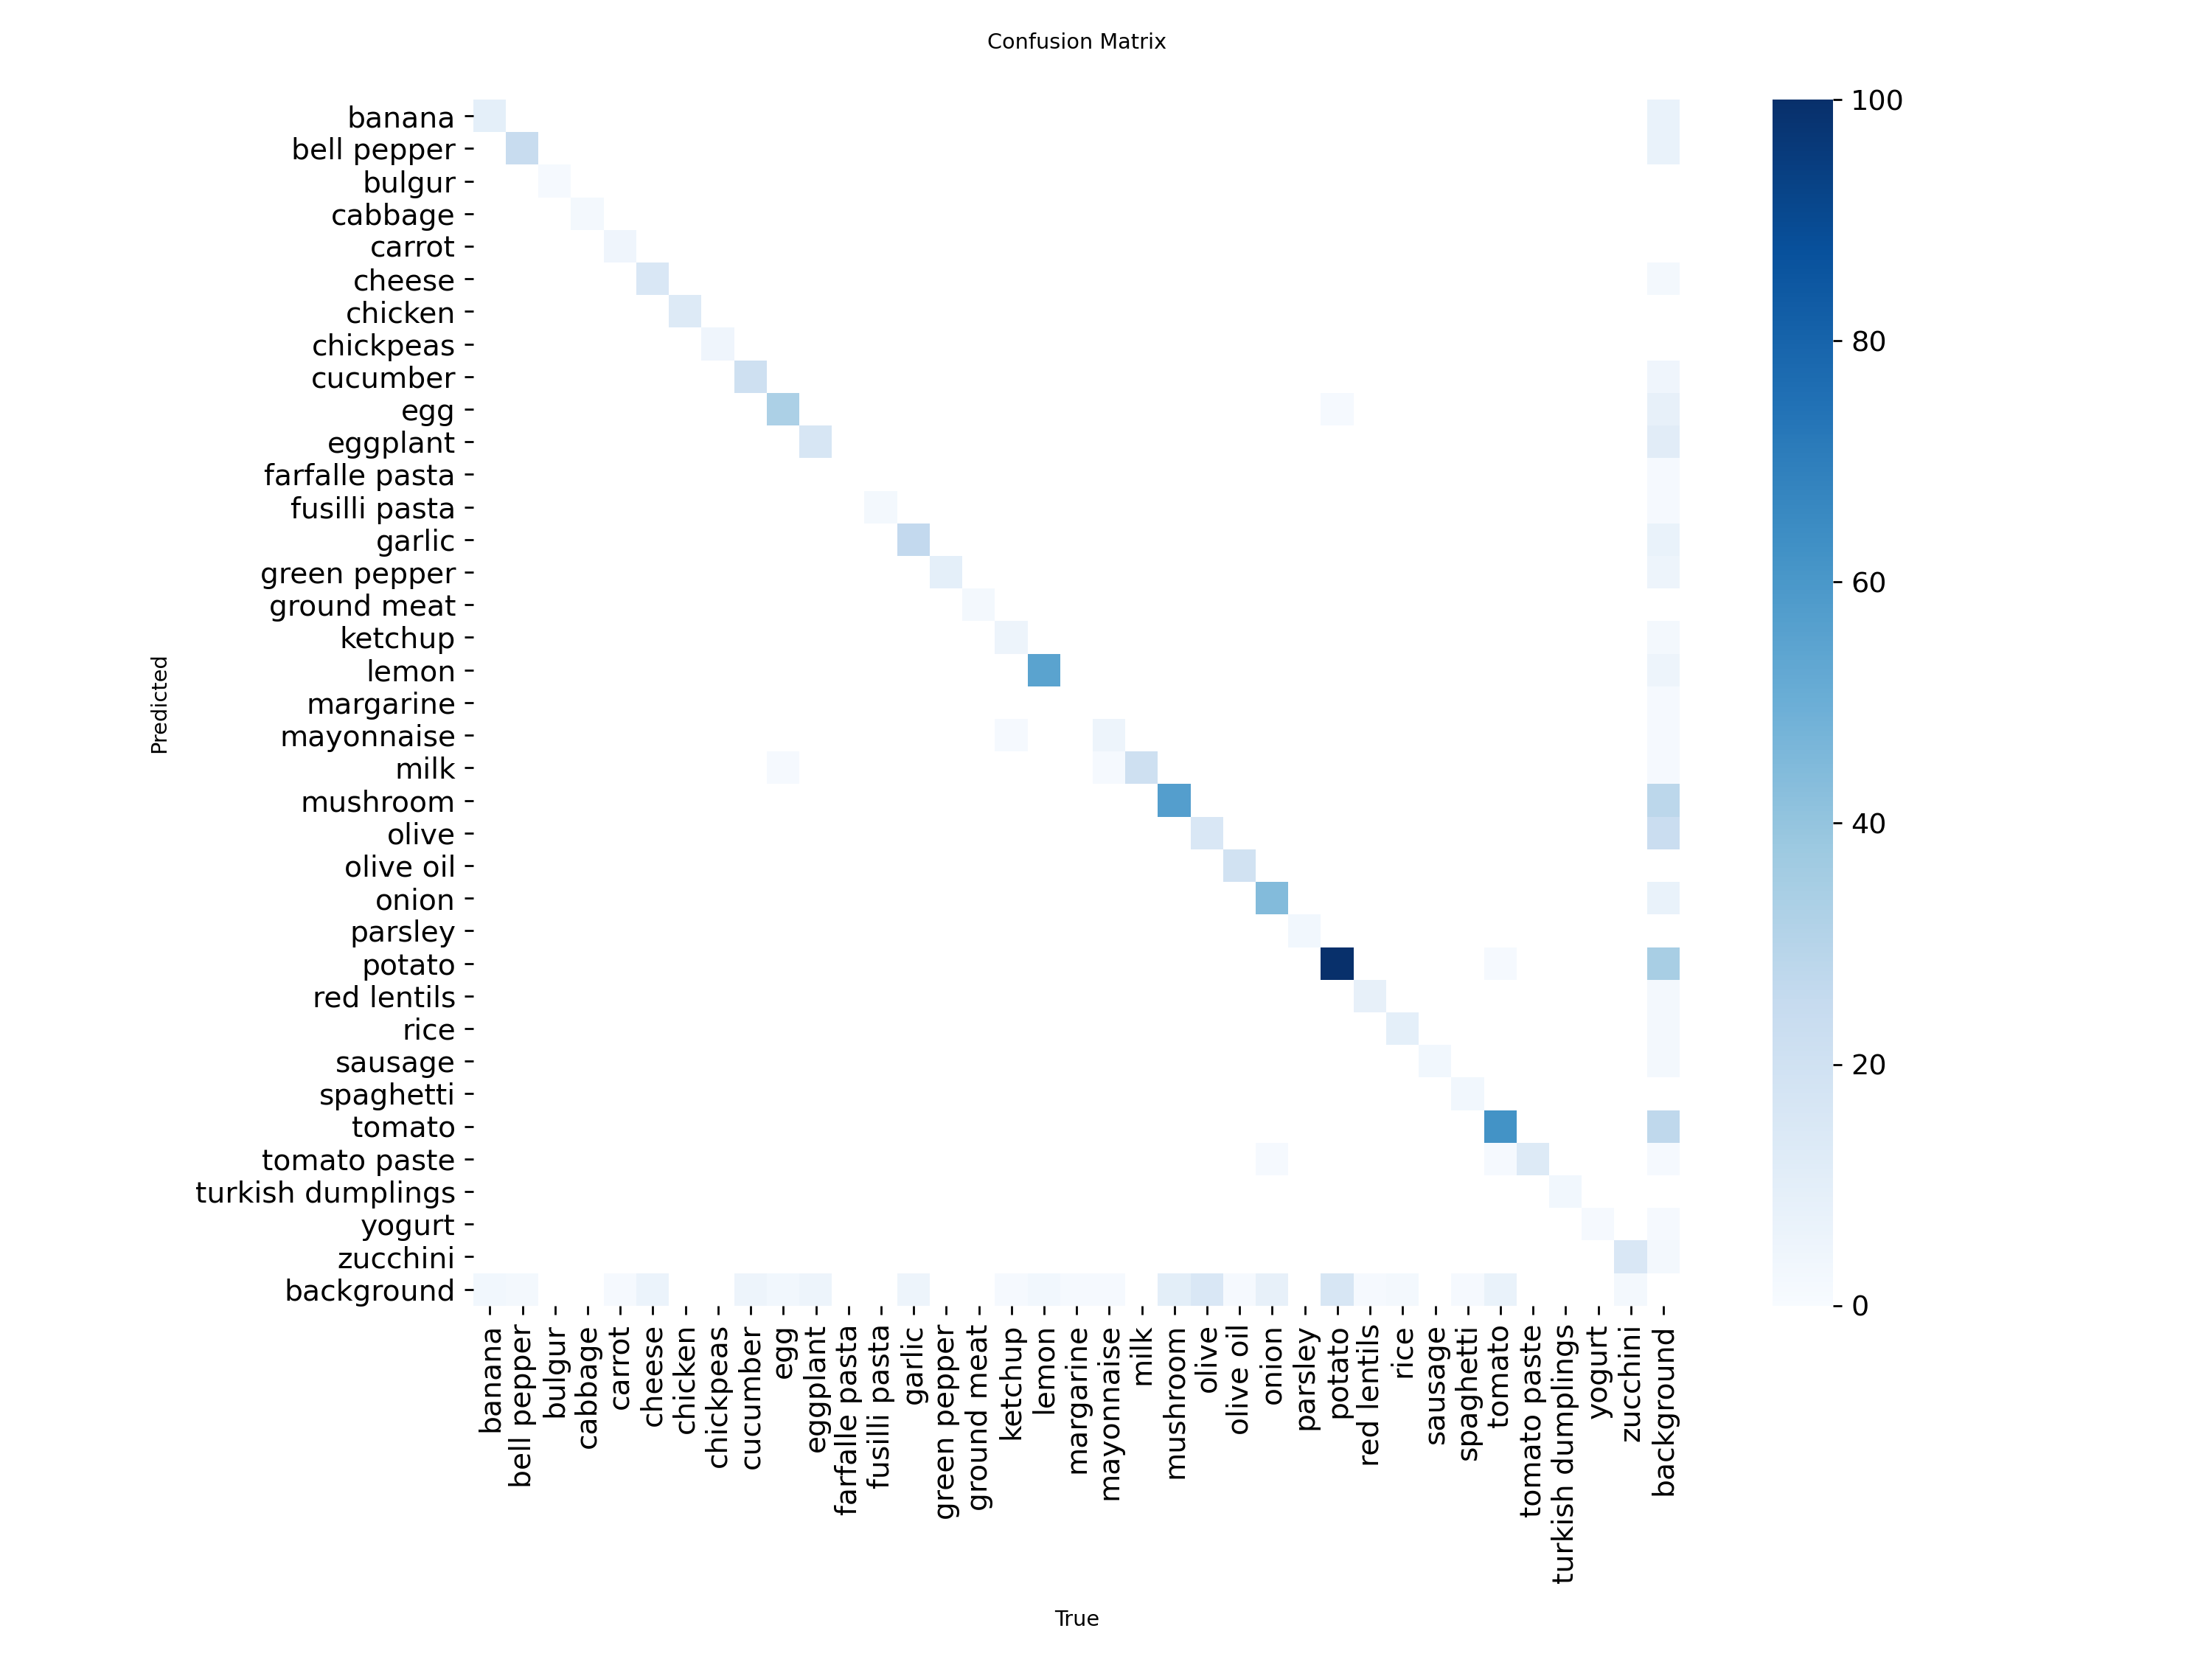

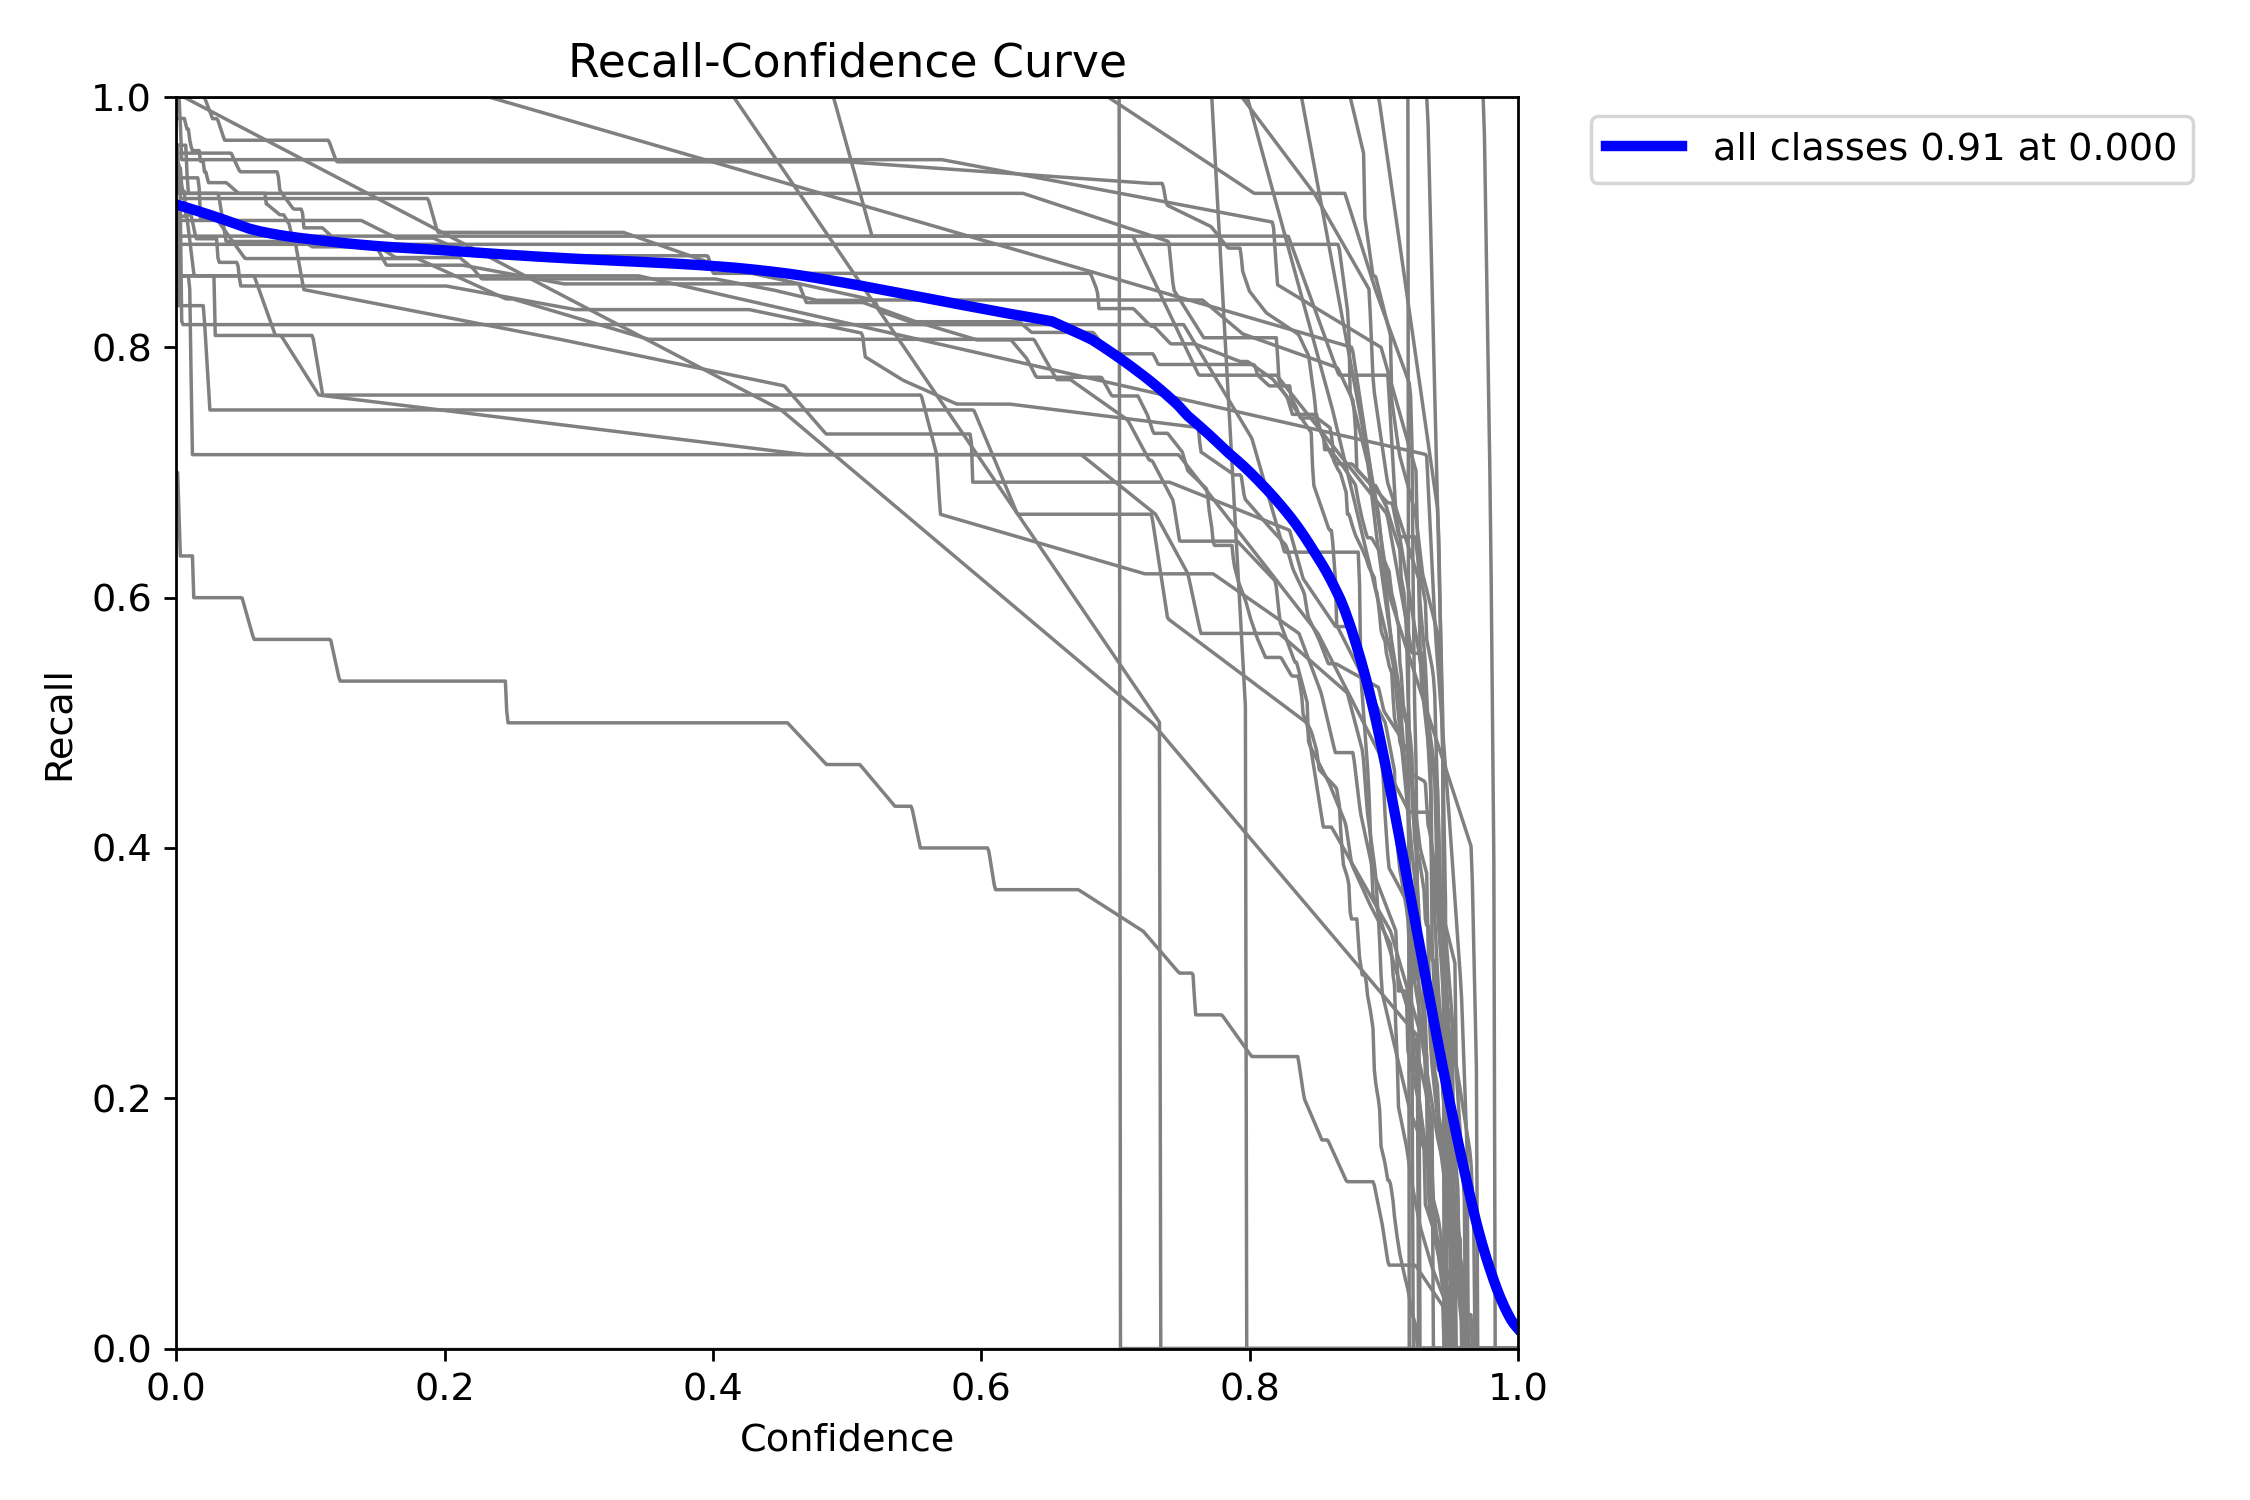

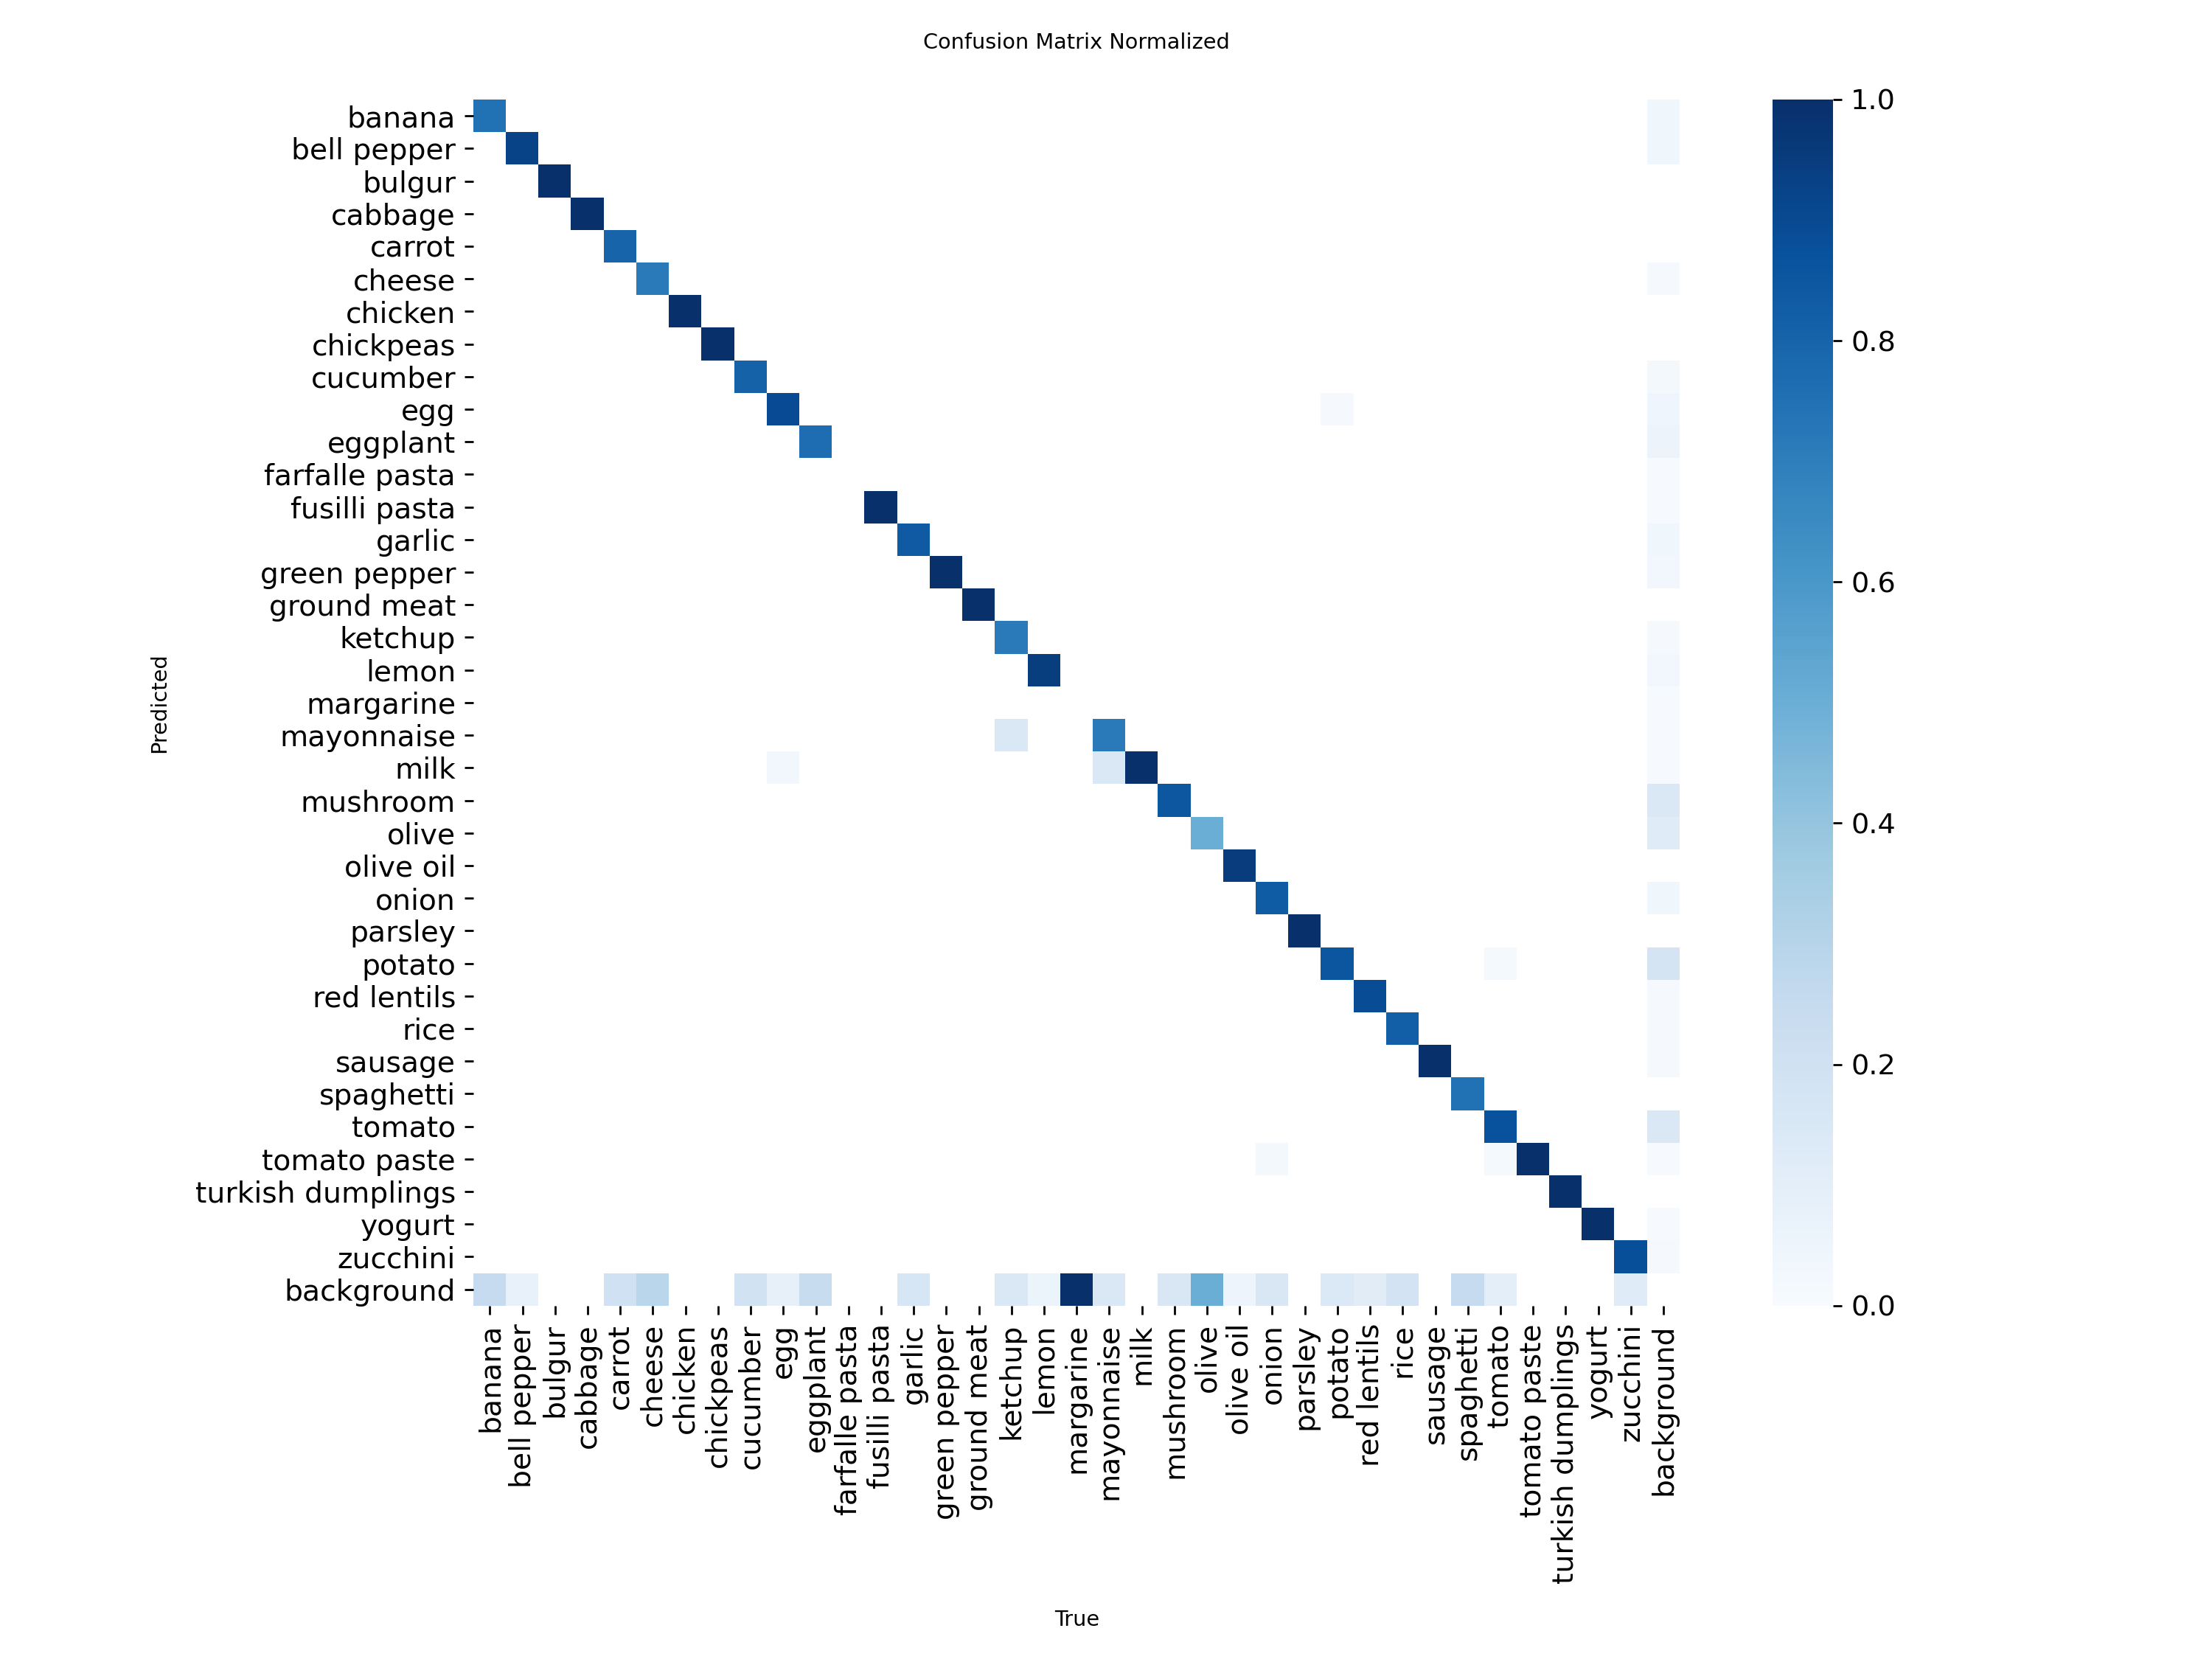

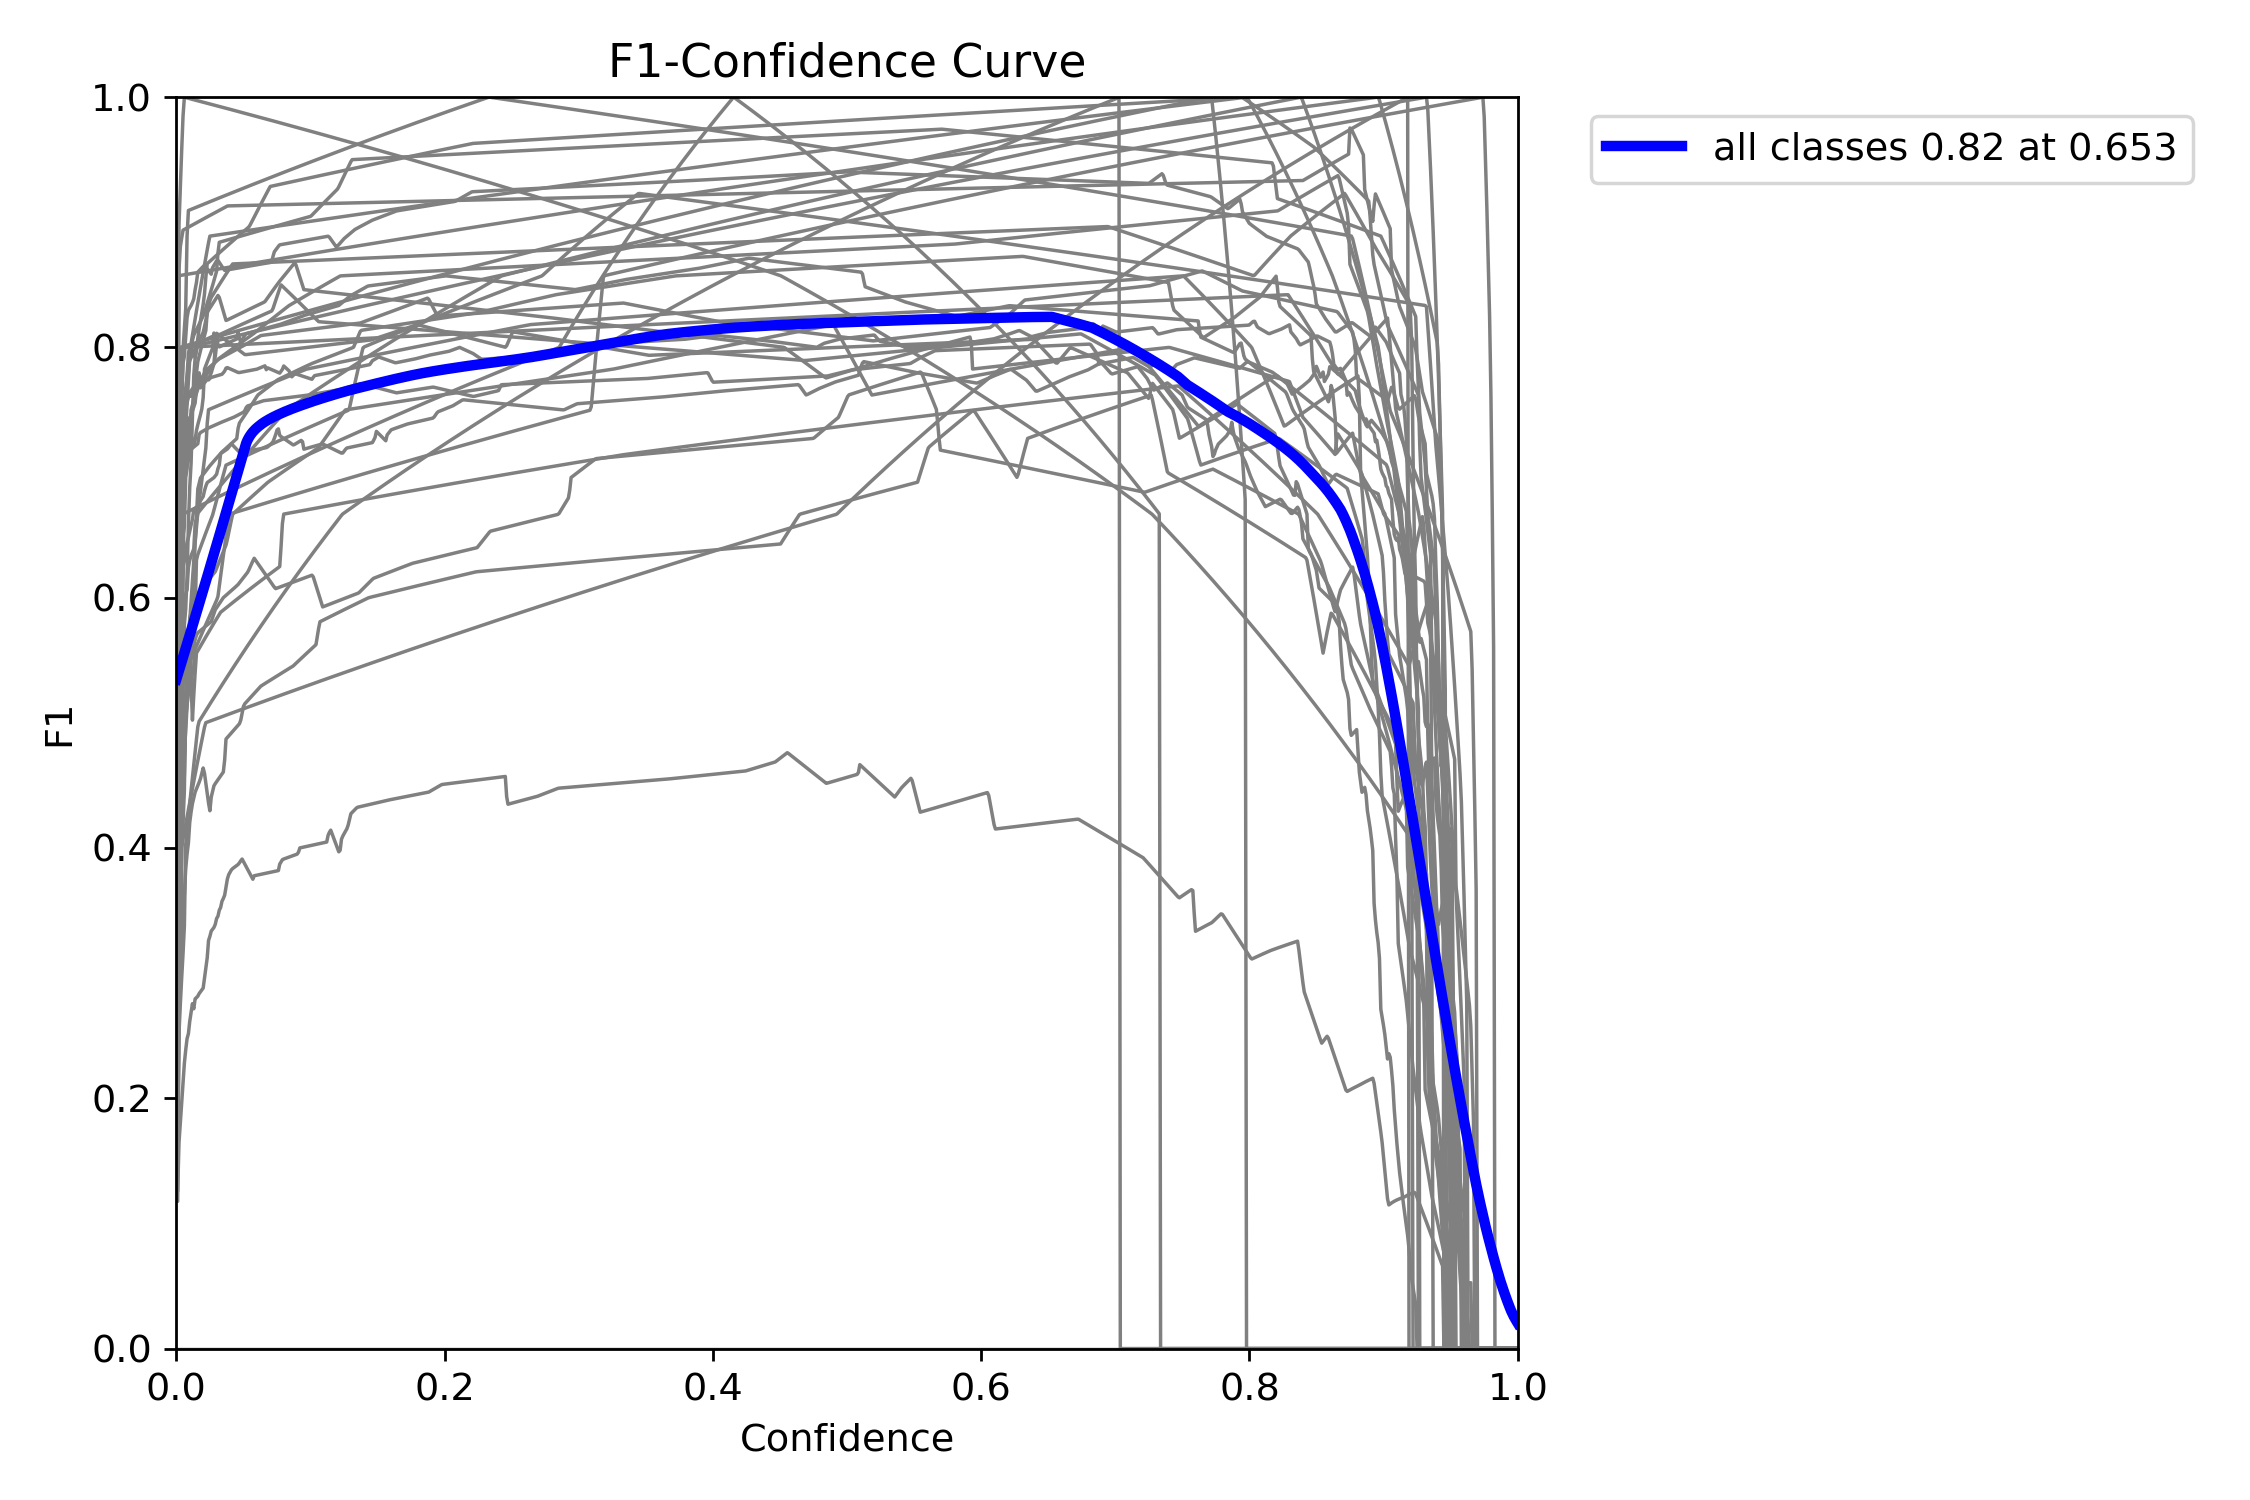

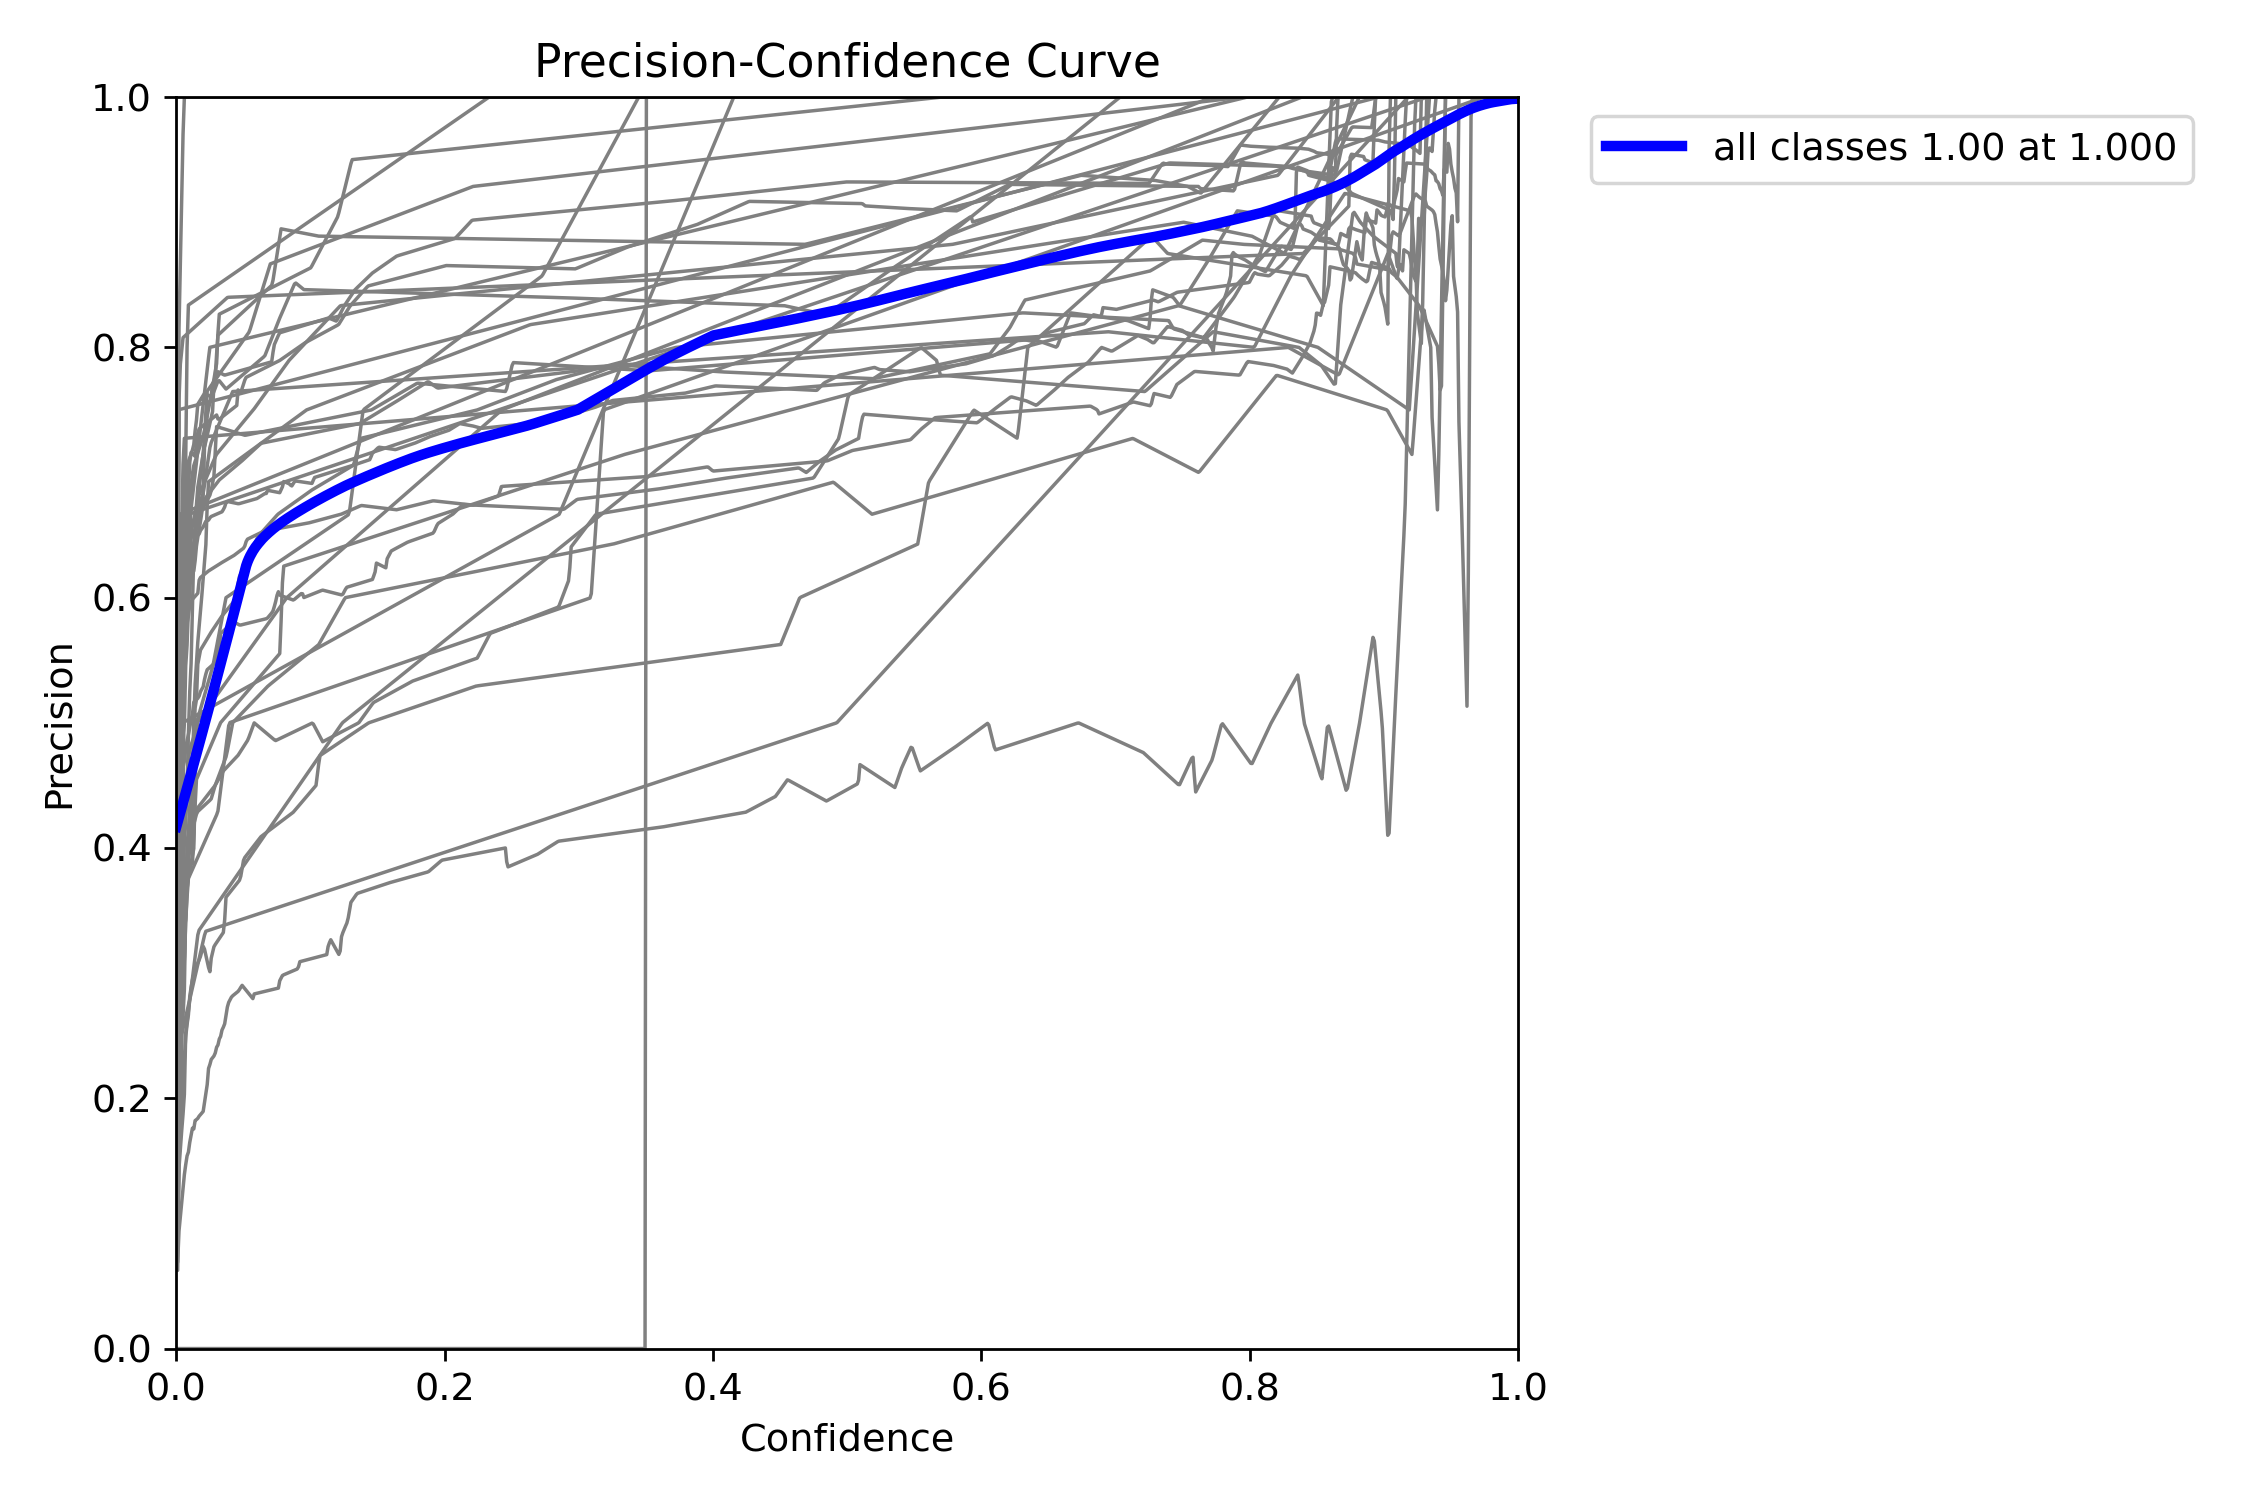

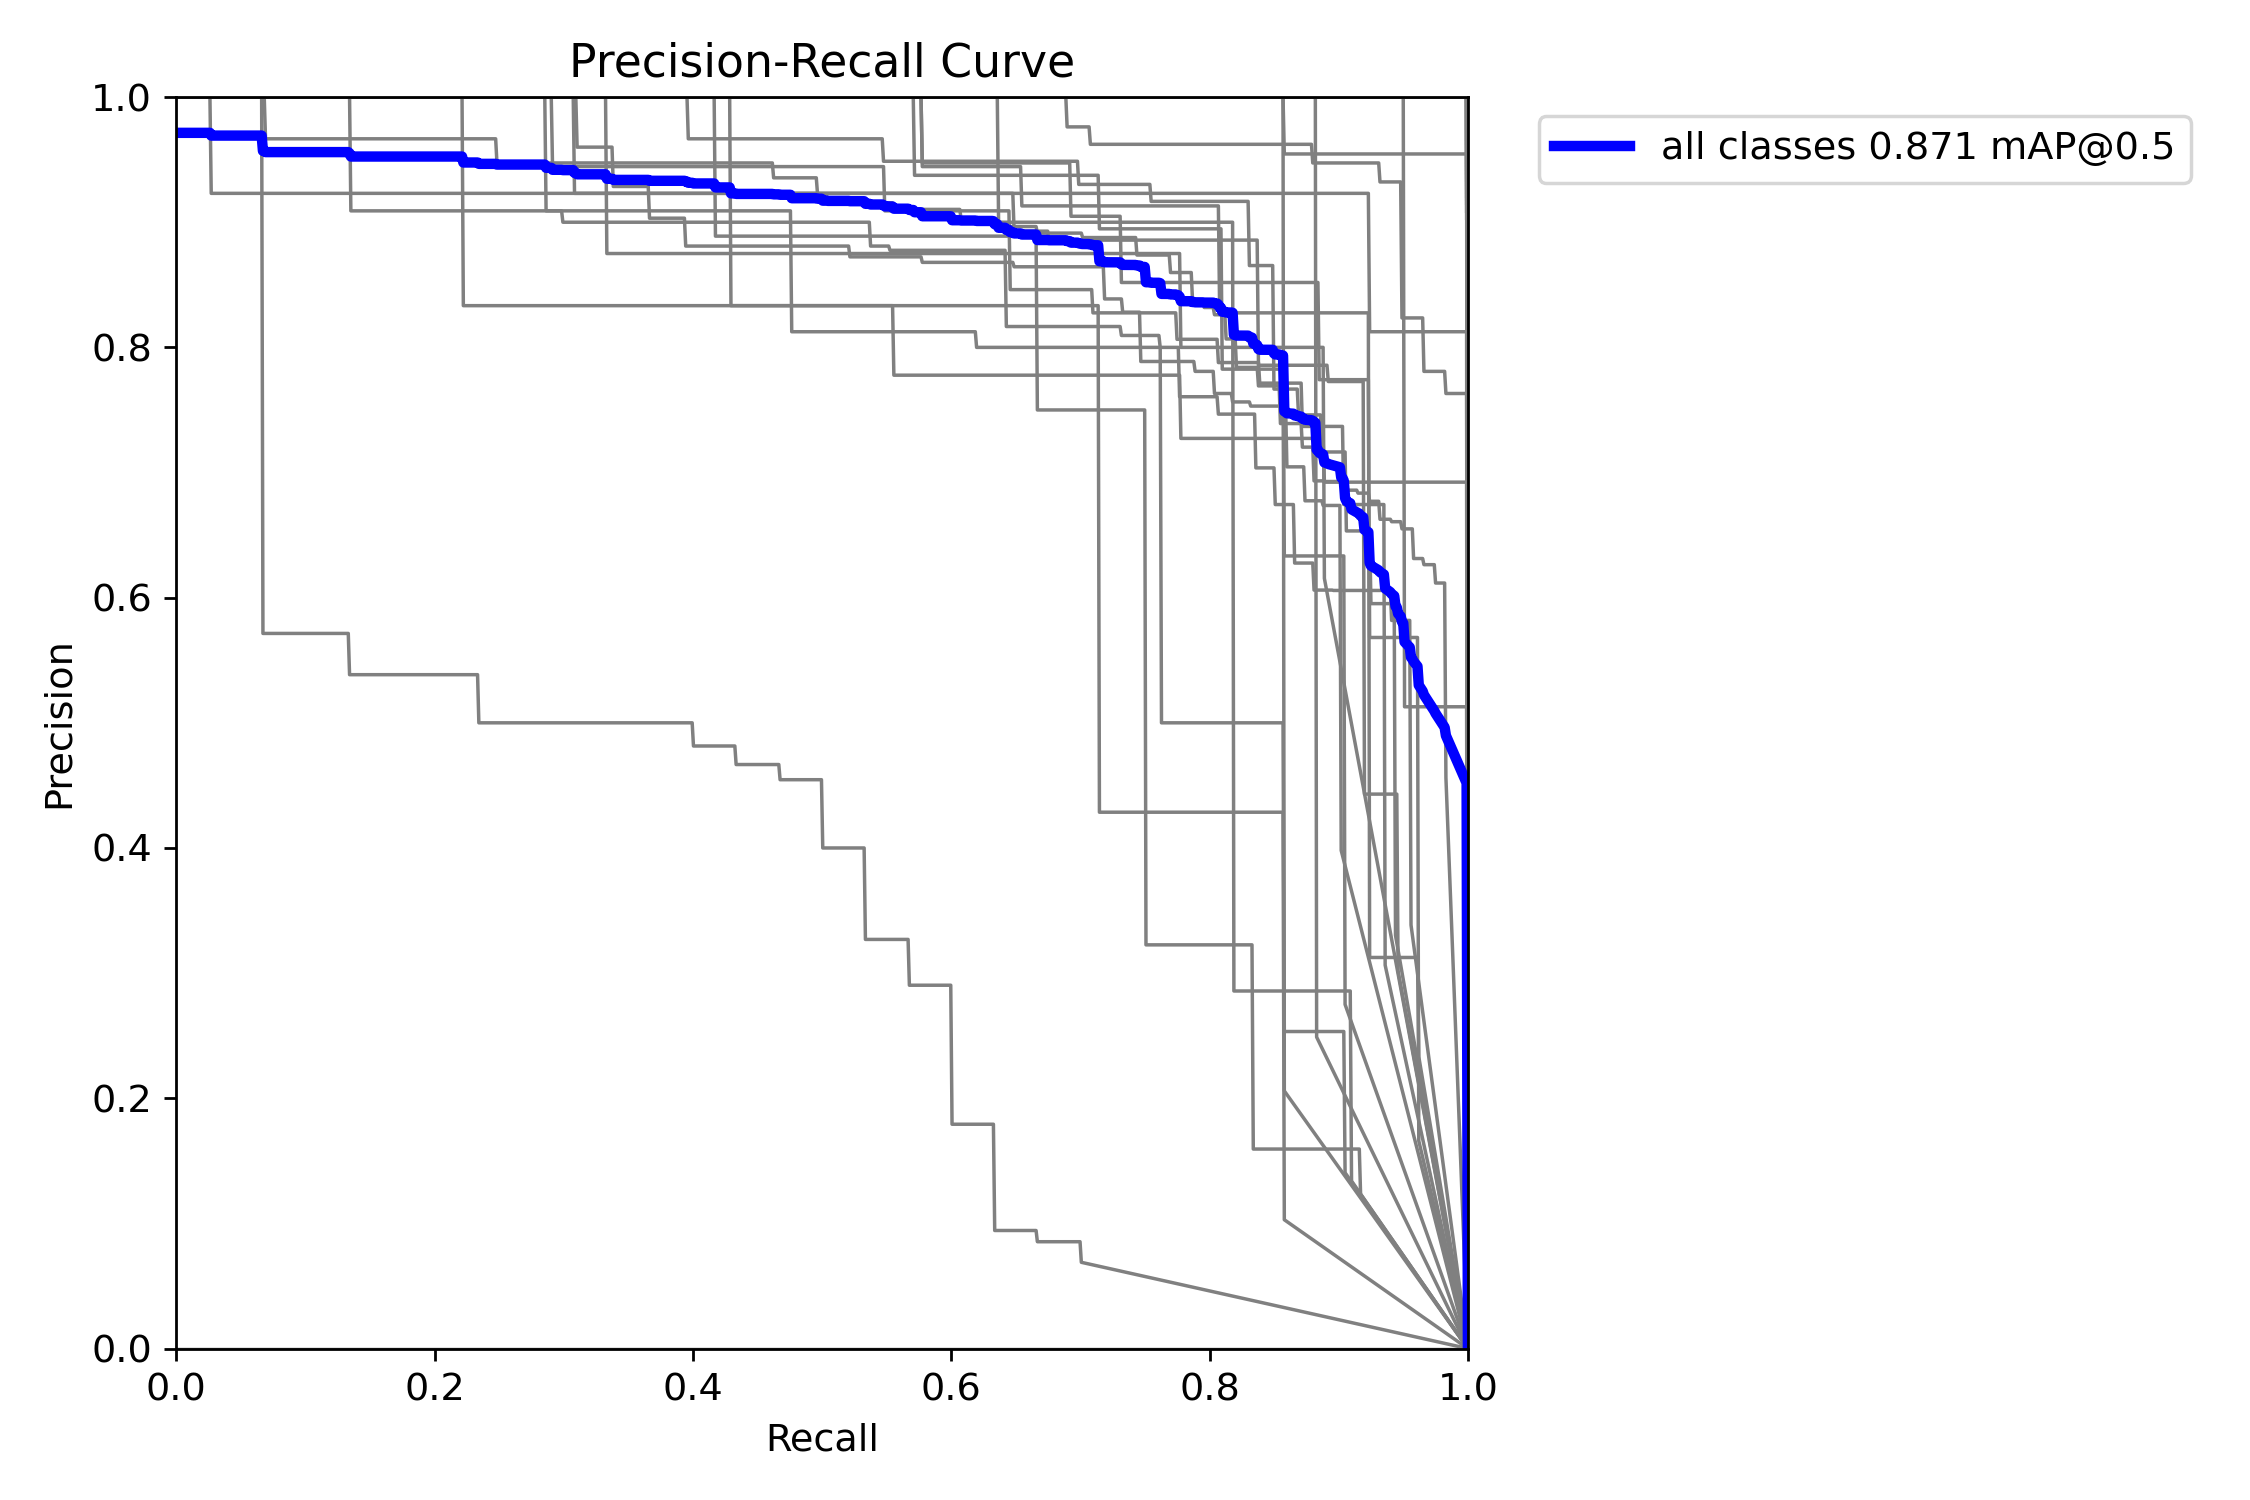

In [46]:
val_images_dir = os.path.join(ROOT_DIR, 'results', 'detect_single_ingredient_images', '100_epochs')

# Display all images in the directory
for image_path in glob.glob(os.path.join(val_images_dir, '*.png')):
    display(Image(filename=image_path, height=400))
    print('\n')